<a href="https://colab.research.google.com/github/AmyvdList/CBS_StatLine_DonorRegister/blob/main/JJ_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Donor Registry Dataset**

The Donor registry data was obtained fom the StatLine databank of the CBS: https://opendata.cbs.nl/#/CBS/nl/navigatieScherm/themaStatLine.

Specifically the dataset downloaded was named "Donorregistratie; persoonskenmerken, 2014-2022" under section "Gezonheid and Welzijn" followed by "Donorregistratie": https://opendata.cbs.nl/#/CBS/nl/dataset/82814NED/table?ts=1774702668634.

Data was filtered to not include all age categories but only consider the total population i.e. filter for 'Persoonskenmerken' = 'Totale bevolking van 12 jaar en ouder'.


**Data Description**

The dataset contains information on the number of individuals and their recorded preferences in the Dutch Donor Register between 2014 and 2022. A description of the variables is provided below:

*   *Donorregistratie*: the recorded choice in the donor register (e.g., consent, refusal, or decision delegated to others)
*   *Persoonskenmerken*: demographic characteristics of individuals, such as age group; selected for 'Totale bevolking van 12 jaar en ouder'.
*   *Perioden*: the year of registration (2014–2022)
*   *Donorregister, vastgelegde keuze (x 1 000)*: the number of individuals (in thousands) with a given registration choice.

In [24]:
# Upload csv dataset
from google.colab import files

uploaded = files.upload()


Saving Donorregistratie_default.csv to Donorregistratie_default (1).csv


In [25]:
import pandas as pd

# Get name of single csv file uploaded
file_name = list(uploaded.keys())[0]

# Read the CSV with semicolon separator
df = pd.read_csv(file_name, sep=';')

# Display the first 5 rows of the DataFrame
display(df.head())

,Donorregistratie,Persoonskenmerken,Perioden,"Donorregister, vastgelegde keuze (x 1 000)"
0,Geregistreerd in donorregister,Totale bevolking van 12 jaar en ouder,2014,5768.6
1,Geregistreerd in donorregister,Totale bevolking van 12 jaar en ouder,2015,5814.5
2,Geregistreerd in donorregister,Totale bevolking van 12 jaar en ouder,2016,5865.6
3,Geregistreerd in donorregister,Totale bevolking van 12 jaar en ouder,2017,6057.6
4,Geregistreerd in donorregister,Totale bevolking van 12 jaar en ouder,2018,6317.8


In [26]:
# Get unique objects (values) for 'Donorregistratie' column
unique_donor_registratie = df['Donorregistratie'].unique()
print(f"Unique objects in 'Donorregistratie':\n{unique_donor_registratie}")

# Get unique objects (values) for 'Persoonskenmerken' column
unique_person_characteristics = df['Persoonskenmerken'].unique()
print(f"\nUnique objects in 'Persoonskenmerken':\n{unique_person_characteristics}")

# Get unique objects (values) for 'Perioden' column
unique_period_values = df['Perioden'].unique()
print(f"\nUnique objects in 'Perioden':\n{unique_period_values}")

Unique objects in 'Donorregistratie':
['Geregistreerd in donorregister' 'Toestemming zonder donatiebeperkingen'
 'Toestemming met donatiebeperkingen' 'Geen toestemming'
 'Nabestaanden beslissen' 'Aangewezen persoon beslist'
 'Geen bezwaar tegen orgaandonatie']

Unique objects in 'Persoonskenmerken':
['Totale bevolking van 12 jaar en ouder']

Unique objects in 'Perioden':
['2014' '2015' '2016' '2017' '2018' '2019' '2020' '2021' '2022*']


In [27]:
# Replace '2022*' with '2022' in the 'Perioden' column
df['Perioden'] = df['Perioden'].str.replace('*', '', regex=False)

# Display the unique values of 'Perioden' to confirm the change
unique_period_values_after_cleaning = df['Perioden'].unique()
print(f"\nUnique objects in 'Perioden' after cleaning:\n{unique_period_values_after_cleaning}")


Unique objects in 'Perioden' after cleaning:
['2014' '2015' '2016' '2017' '2018' '2019' '2020' '2021' '2022']


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for data on total population
# Include only 'Totale bevolking van 12 jaar en ouder' (not interested in all age categories seperately)
filtered_df_stacked = df[
    (df['Persoonskenmerken'] == 'Totale bevolking van 12 jaar en ouder')
].copy()

# Convert 'Perioden' to numeric
filtered_df_stacked['Perioden'] = pd.to_numeric(filtered_df_stacked['Perioden'], errors='coerce')

# Clean and convert the y-axis column to numeric
filtered_df_stacked['Donorregister, vastgelegde keuze (x 1 000)'] = filtered_df_stacked['Donorregister, vastgelegde keuze (x 1 000)'].replace('.', pd.NA)
filtered_df_stacked['Donorregister, vastgelegde keuze (x 1 000)'] = pd.to_numeric(filtered_df_stacked['Donorregister, vastgelegde keuze (x 1 000)'], errors='coerce')

# Drop rows where 'Perioden' or the y-axis column are NaN after conversion
filtered_df_stacked.dropna(subset=['Perioden', 'Donorregister, vastgelegde keuze (x 1 000)'], inplace=True)

# Define mapping
action_map = {
    'Toestemming zonder donatiebeperkingen': 'action_favor',
    'Toestemming met donatiebeperkingen': 'action_favor',
    'Nabestaanden beslissen': 'action_neutral',
    'Aangewezen persoon beslist': 'action_neutral',
    'Geen toestemming': 'action_against',
    'Geen bezwaar tegen orgaandonatie': 'inaction_favor'
}

# Create new column with action category
filtered_df_stacked['action_type'] = filtered_df_stacked['Donorregistratie'].map(action_map)

# Only keep relevant rows (those with action types)
df_result = filtered_df_stacked[filtered_df_stacked['action_type'].notna()]

/tmp/ipykernel_5002/3878486475.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result['Perioden'] = pd.to_numeric(df_result['Perioden'], errors='coerce')


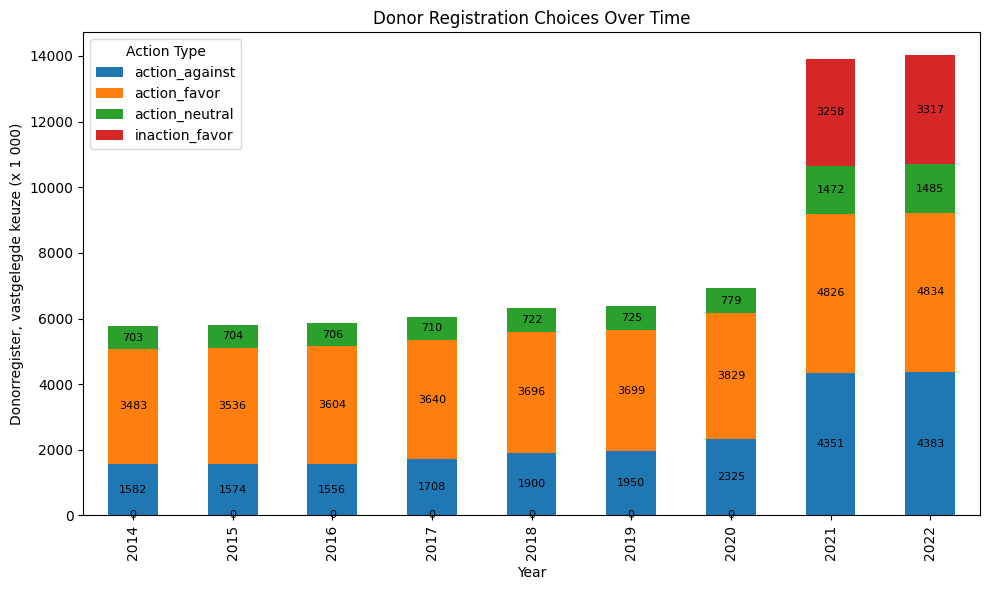

In [30]:
# Make sure 'Perioden' is numeric
df_result['Perioden'] = pd.to_numeric(df_result['Perioden'], errors='coerce')

# Aggregate per year and action_type
grouped = (
    df_result
    .groupby(['Perioden', 'action_type'])['Donorregister, vastgelegde keuze (x 1 000)']
    .sum()
    .reset_index()
)

# Pivot to wide format (for stacked bar graph)
pivot_df = grouped.pivot(
    index='Perioden',
    columns='action_type',
    values='Donorregister, vastgelegde keuze (x 1 000)'
).fillna(0)


# Plot
ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

# Add labels
for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        fmt='%.0f',
        fontsize=8
    )

plt.xlabel('Year')
plt.ylabel('Donorregister, vastgelegde keuze (x 1 000)')
plt.title('Donor Registration Choices Over Time')
plt.legend(title='Action Type')
plt.tight_layout()
plt.show()